In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
fake_df=pd.read_csv("C:\\Users\\satya\\OneDrive\\Desktop\\fake-news-project\\data\\Fake.csv")
true_df=pd.read_csv("C:\\Users\\satya\\OneDrive\\Desktop\\fake-news-project\\data\\True.csv")

print(fake_df.head())
print(true_df.head())


                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [3]:
fake_df['label'] = 0
true_df['label'] = 1


In [4]:
df = pd.concat([fake_df, true_df], axis=0)

print(df.shape)

(44898, 5)


In [5]:
print(df['label'].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [6]:
df['content'] = df['title'] + " " + df['text']
df.head()
#added new columns content by just merging two columns text and title


,title,text,subject,date,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...


In [7]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [8]:
print(df.head())
print(df.info())
print(df['label'].value_counts())

                                               title  \
0  Ben Stein Calls Out 9th Circuit Court: Committ...   
1  Trump drops Steve Bannon from National Securit...   
2  Puerto Rico expects U.S. to lift Jones Act shi...   
3   OOPS: Trump Just Accidentally Confirmed He Le...   
4  Donald Trump heads for Scotland to reopen a go...   

                                                text       subject  \
0  21st Century Wire says Ben Stein, reputable pr...       US_News   
1  WASHINGTON (Reuters) - U.S. President Donald T...  politicsNews   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...  politicsNews   
3  On Monday, Donald Trump once again embarrassed...          News   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...  politicsNews   

                  date  label  \
0    February 13, 2017      0   
1       April 5, 2017       1   
2  September 27, 2017       1   
3         May 22, 2017      0   
4       June 24, 2016       1   

                                           

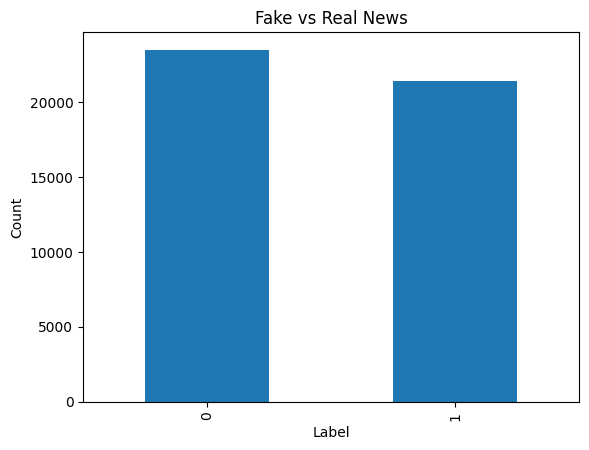

In [9]:
#fake vs real news
df['label'].value_counts().plot(kind='bar')
plt.title("Fake vs Real News")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

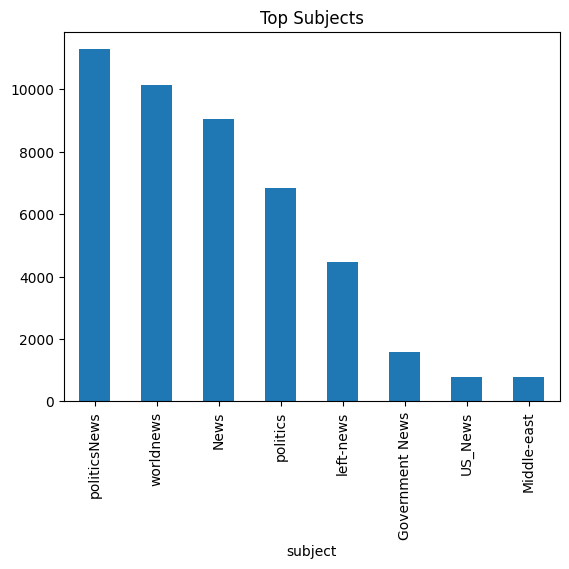

In [10]:
#News by Subject
df['subject'].value_counts().head(10).plot(kind='bar')
plt.title("Top Subjects")
plt.show()

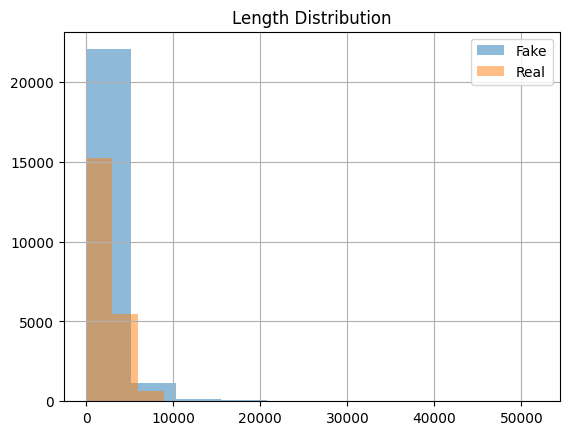

In [11]:
#Article length
df['length'] = df['text'].apply(len)

df[df['label']==0]['length'].hist(alpha=0.5, label='Fake')
df[df['label']==1]['length'].hist(alpha=0.5, label='Real')

plt.legend()
plt.title("Length Distribution")
plt.show()

In [12]:
#NLP analysis
from collections import Counter

all_words = " ".join(df['text']).split()
Counter(all_words).most_common(20)

[('the', 905825),
 ('to', 529815),
 ('of', 437532),
 ('and', 392470),
 ('a', 390084),
 ('in', 322378),
 ('that', 220928),
 ('on', 181758),
 ('s', 172259),
 ('for', 166256),
 ('is', 160009),
 ('was', 114171),
 ('with', 113690),
 ('he', 105668),
 ('Trump', 101305),
 ('as', 96723),
 ('The', 95236),
 ('said', 93137),
 ('by', 92699),
 ('his', 92058)]

In [13]:
# HERE DATA SCIENCE STARTS

In [14]:
#Text cleaning
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['content'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\satya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_text'])
y = df['label']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9883073496659243


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[4626   70]
 [  35 4249]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



In [20]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [21]:
def predict_news(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)
    
    if prediction[0] == 0:
        return "Fake News ❌"
    else:
        return "Real News ✅"